# Email Unsubscribe / Spam Guardrail – Survival-Analysis

> **Goal** Build a lightweight, data-driven “cool-down” policy that prevents a brand from emailing a subscriber when the risk of *unsubscribe* or *spam complaint* spikes protecting deliverability without killing revenue.

---

## 1 .  Dataset
* **`touchpoint-lab/data/raw_events.csv`** – 20 k synthetic Klaviyo-style events  
  * `profile_id` subscriber identifier  
  * `event_ts` ISO timestamp  
  * `event_name` free-text (opens, clicks, SMS sent, etc.)  
  * `purchased_7d` label used elsewhere; **not** needed here  
* **Negative signals** – rows whose `event_name` ∈  
```json
    { "Unsubscribed",
    "Clicked email to unsubscribe",
    "Marked Spam",
    "Spam Complaint" }
```

---

## 2 .  Modelling Approach
| Stage | Technique | Why |
|-------|-----------|-----|
| **Survival framing** | *duration* = days from first event → first unsubscribe; censored if none | Handles​ “time-to-churn” natively |
| **Estimator** | `RandomSurvivalForest` (lifelines) | Non-parametric, robust to non-linearities |
| **Risk metric** | **7-day cumulative hazard** = 1 – S(7) | Intuitive “probability of churn next week” |
| **Policy** | `cool_down_days = min(30, max(0, 7 × risk/τ))` with τ = 2 % | Linear mapping; 0 → safe, 1–30 d → pause window |

---

## 3 .  Notebook Contents
1. **Load & feature-engineer**  ➜ `n_events_24h`, `pct_brand_actions`  
2. **Train RandomSurvivalForest** and print concordance-index  
3. **Visualise survival curves** for low, medium, high-risk profiles  
4. **Cool-down rule** – demo predictions  
5. **Next steps** – add campaign context, brand-specific thresholds, real-time feature store

> *Run all cells ➜ you’ll get a survival plot and see how the guardrail converts risk into a pause window.*

---


In [1]:
from pathlib import Path
import guardrail_model as gm
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [2]:
gm.train_guardrail(
    Path("../data/raw_events.csv"),
    Path("../models/guardrail_rsforest.pkl"),
)

Training concordance-index ≈ 0.115
✓ guardrail model saved → ../models/guardrail_rsforest.pkl


In [3]:
def make_feature_matrix(**kwargs):
    order = ["n_events_24h", "pct_brand_actions",
             "days_since_last_event", "opens_last30d"]
    return np.array([[kwargs.get(k, 0.0) for k in order]], dtype=float)

In [4]:
rsf = joblib.load("../models/guardrail_rsforest.pkl")
X = np.vstack([
    make_feature_matrix(n_events_24h=1, pct_brand_actions=0.02,
                        days_since_last_event=3, opens_last30d=1),
    make_feature_matrix(n_events_24h=3, pct_brand_actions=0.10,
                        days_since_last_event=7, opens_last30d=0),
    make_feature_matrix(n_events_24h=6, pct_brand_actions=0.40,
                        days_since_last_event=14, opens_last30d=0),
])
curves = rsf.predict_survival_function(X, return_array=True)

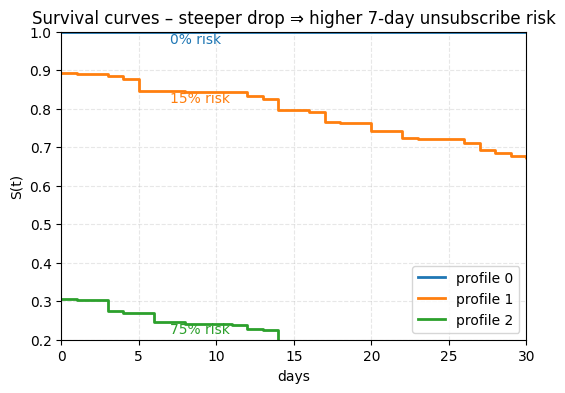

In [9]:
fig, ax = plt.subplots(figsize=(6,4))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for idx, (sf, col) in enumerate(zip(curves, colors)):
  ax.step(range(sf.size), sf, where="post", lw=2, color=col,
          label=f"profile {idx}")
  risk7 = 1 - sf[min(7, sf.size-1)]
  ax.text(7, sf[min(7, sf.size-1)]-0.03,
          f"{risk7:.0%} risk", color=col)

ax.set_ylim(0.2, 1)
ax.set_xlim(0, 30)
ax.set_xlabel("days")
ax.set_ylabel("S(t)")
ax.set_title("Survival curves – steeper drop ⇒ higher 7-day unsubscribe risk")
ax.grid(alpha=.3, ls="--")
ax.legend(loc="lower right")

#### Verify

In [15]:
from pathlib import Path
import pandas as pd, numpy as np, joblib

from guardrail_model import load_training_frame

events_csv = Path("../data/raw_events.csv")
model_pkl  = Path("../models/guardrail_rsforest.pkl")

ev  = pd.read_csv(events_csv, parse_dates=["event_ts"])
rsf = joblib.load(model_pkl)

df = load_training_frame(events_csv)

X = df[[
        "n_events_24h",
        "pct_brand_actions",
        "days_since_last_event",
        "opens_last30d",
     ]].to_numpy()

sf_all = rsf.predict_survival_function(X, return_array=True)
risk7  = 1 - np.array([sf[min(7, sf.size-1)] for sf in sf_all])
df["risk7"] = risk7

# did they churn within 7 days?
UNSUB = {"Unsubscribed", "Clicked email to unsubscribe",
         "Marked Spam", "Spam Complaint"}
first_unsub = (
    ev[ev.event_name.isin(UNSUB)]
      .groupby("profile_id").event_ts.min()
)

df["churn_7d"] = df.apply(
    lambda r: r.profile_id in first_unsub.index and
              (first_unsub[r.profile_id] - r.first_seen_ts).days <= 7,
    axis=1,
)

In [16]:
print(
    df.sort_values("risk7", ascending=False)
      .head(10)[["profile_id",
                 "n_events_24h",
                 "pct_brand_actions",
                 "days_since_last_event",
                 "opens_last30d",
                 "risk7",
                 "churn_7d"]]
)

      profile_id  n_events_24h  pct_brand_actions  days_since_last_event  \
386          388           1.0           0.666667                    9.0   
2517        2521           1.0           0.666667                   14.0   
1829        1832           1.0           0.714286                   44.0   
2266        2270           2.0           0.750000                   60.0   
939          942           1.0           0.666667                   48.0   
2274        2278           1.0           0.666667                   12.0   
207          209           1.0           0.600000                   10.0   
1901        1904           1.0           0.666667                   37.0   
2456        2460           1.0           1.000000                   14.0   
476          478           1.0           0.666667                   10.0   

      opens_last30d     risk7  churn_7d  
386             0.0  0.950559      True  
2517            0.0  0.943791      True  
1829            0.0  0.942907      Tr

#### sanity check to confirm lift

In [20]:
df["bucket"] = pd.qcut(df["risk7"], 10, labels=False, duplicates="drop")

lift = (
    df.groupby("bucket", observed=True)["churn_7d"]
      .mean()
      .rename("churn_rate")
)

print(lift)


bucket
0    0.000000
1    0.057627
2    0.199336
3    0.345638
4    0.445183
5    0.719064
Name: churn_rate, dtype: float64
